Content
1. DP Basics
2. 0/1 Knapsack
3. Unbounded Knapsack
4. Longest Common Subsequence
5. Matrxi Chain Multiplication
6. DP on Trees




In [ ]:
Dynamic Programming (DP) is an optimization technique used to solve problems by breaking them down into overlapping subproblems and storing their results to avoid redundant computations. It is mainly used when a problem has:
	1.	Optimal Substructure – The solution to a problem can be constructed using solutions to its subproblems.
	2.	Overlapping Subproblems – The same subproblems are solved multiple times.


DP solves problems by storing solutions to subproblems in a table (memoization or tabulation) so that each subproblem is solved only once, reducing the time complexity significantly.

Types of DP Approaches:
	1.	Top-Down (Memoization) – Recursion with caching of computed results.
	2.	Bottom-Up (Tabulation) – Iteratively solving small subproblems first and using their results to solve larger ones.


How to Recognize DP Problems in Interviews?
- Recursion with multiple choice in answer space. (whether to take or not an element)
- Problem statement asking for optimal answer. (like min, max, largest, No. of ways)
- Using a subset for final Ans
- If there are multiple calls on a tree branch  

	1.	Does the problem have optimal substructure?
	•	Can you break it into smaller subproblems that can be reused?
	2.	Does it involve decision-making at each step?
	•	Choosing elements, making moves, or maximizing/minimizing something.
	3.	Does the problem have overlapping subproblems?
	•	Is the same subproblem solved multiple times?
	4.	Can brute force give an exponential complexity?
	•	If yes, DP might help optimize it.

Solution approach:
- Write recursive solution, then convert it to Memoization or write top-down.
- DP = Recursion + Storage

Problems:
1. 0-1 Knapsack
   - There are few problems where value array is not given.
   - Input: A Bag (W) and a value array which is a list of few items. 
   - Solution Choice: For each item, we need to check if we should take or not take that item.
                
2. Unbounded Knapsack
3. Fibonacci
4. LCS, LIS
5. Kadane's Algorithm
6. Matrix chain multiplication
7. DP on Trees.
8. DP on Grid.
9. Others.


                   
DP is commonly used in problems that involve:
✅ Combinatorial problems – Counting ways to arrange elements (e.g., coin change, climbing stairs).
✅ Optimization problems – Finding the best possible outcome (e.g., knapsack problem, shortest path).
✅ Sequence-based problems – Working with arrays, strings, or subsequences (e.g., Longest Common Subsequence).
✅ Game theory – Finding the best moves in games (e.g., minimax algorithm).
✅ Graph algorithms – Finding shortest paths and optimal paths in graphs (e.g., Floyd-Warshall, Bellman-Ford).
✅ Substring/subsequence problems – Finding patterns in strings (e.g., palindrome partitioning).

Identify DP problems:
0/1 Knapsack
- Given with either Weight and Value array or just weight array, and a Bag/ W/ total weight/ total sum.

Unbounded Knapsack
- same as 0/1, with the condition same element can be included multiple times.

LCS
- Given two strings and some optimal query is asked.
- Given one string with palindromic, and second string is function(string1) and used as input.

    

# 0/1 Knapsack Problem

In [ ]:
Problem Type 1: franction knapsack: half/ franction of item can be added (Greedy approach)
Problem Type 2: 0/1: Either complete item or not (DP)
Problem Type 3: Unbounded Knapsack: Same item can be added multiple times.

- Input: Given a few items with weight and value.
- Input: Maximum weight that our bag can hold.

- Choice Diagram
1. if item_weight <= bag_weight
   Case 1: We will include the item
   Case 2: We will not include the item
2. if item_weight > bag_weight
   Case 1: We will not include the item

Question 1: Return maximum profit (i.e value)
Weight_Array (wt) = [1, 3, 4, 5]
Value_Array (val) = [1, 4, 5, 7]
Bag_Capacity (W) = 7
n = size of array

In Recursion: With each iteration, input either should increase or decrease. Preferably descrasing.

def knapsack(wt, val, W, n)
    - Base Condition: Think of smallest valid input
    - Choice Diagram 


def knapsack_recursive(weights, values, W, n)
    """ TC: O(2^n) → Because for each item, we have two choices (include/exclude), leading to an exponential number of function calls.

    """
    # Base Case: No items left or knapsack is full
    if n == 0 or W == 0:
        return 0

    # If the item is too heavy, skip it
    if weights[n - 1] > W:
        return knapsack_recursive(weights, values, W, n - 1)

    # Choose the maximum between including or excluding the current item
    else:
        include = values[n - 1] + knapsack_recursive(weights, values, W - weights[n - 1], n - 1)
        exclude = knapsack_recursive(weights, values, W, n - 1)
        return max(include, exclude)     


# The each cell in n*M matrix represent, the maximum profit for W -> weight, n 
def knapsack_recursive_dp(weights, values, W, n, dp)
    """ TC: O(n*W) → Because for each item, we have two choices (include/exclude), leading to an exponential number of function calls.

    """
    # Base Case: No items left or knapsack is full
    if n == 0 or W == 0:
        return 0

    if dp[n][W] != -1:
        return dp[n][W]
        
    # If the item is too heavy, skip it
    if weights[n - 1] > W:
        dp[n][W] =  knapsack_recursive(weights, values, W, n - 1, dp)

    # Choose the maximum between including or excluding the current item
    else:
        include = values[n - 1] + knapsack_recursive(weights, values, W - weights[n - 1], n - 1, dp)
        exclude = knapsack_recursive(weights, values, W, n - 1, dp)
        dp[n][W] =  max(include, exclude)     
    return dp[n][W]

W = 50
n = len(values)
dp = [[-1] * (W + 1) for _ in range(n + 1)]
print("Maximum knapsack value (Memoized):", knapsack_memo(weights, values, W, n, dp))

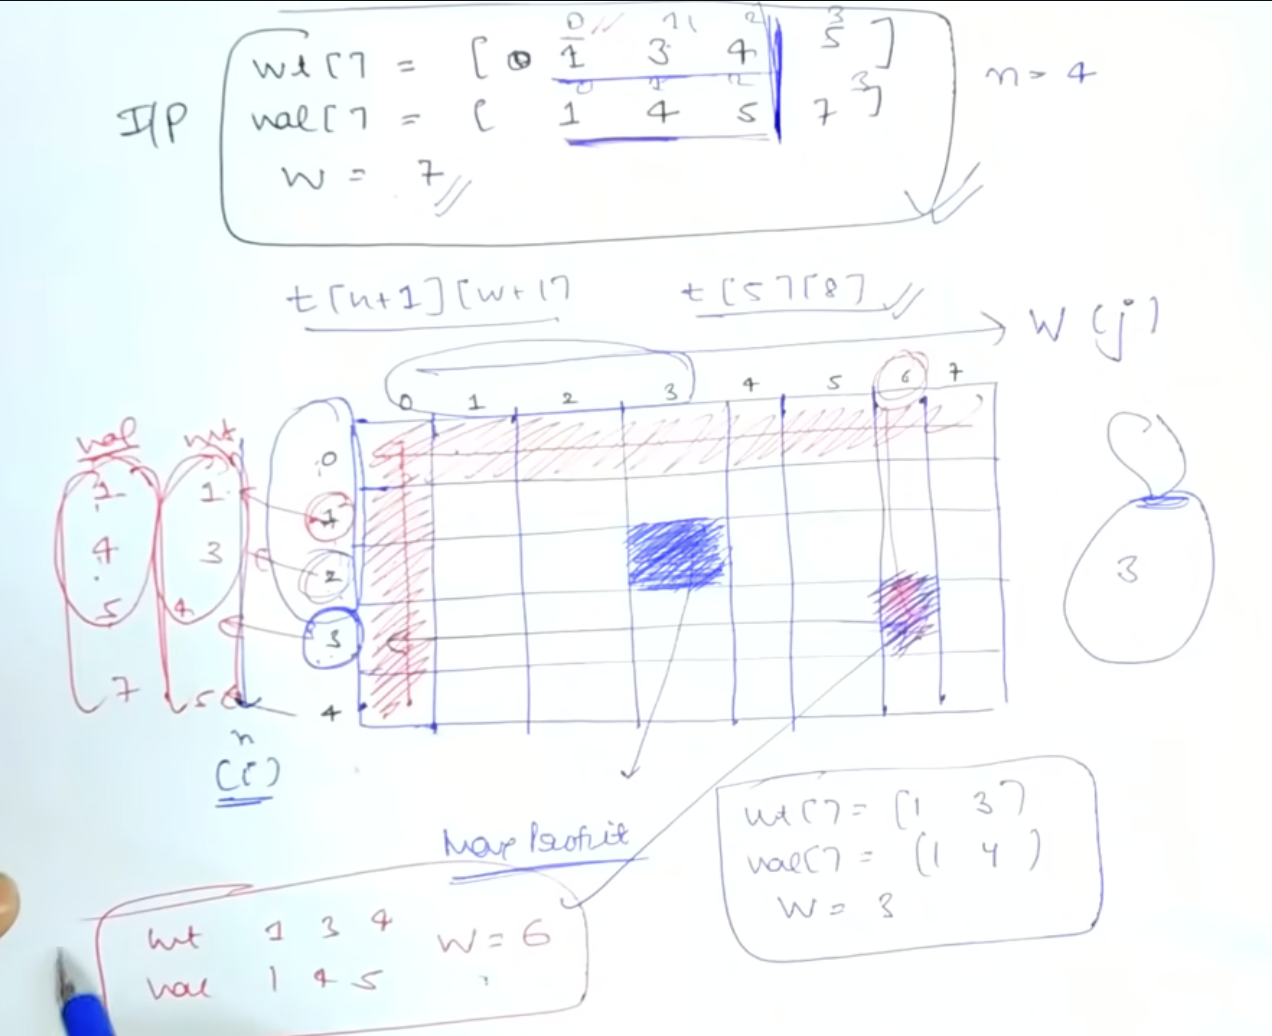

In [ ]:
The value of t[2][3], represents if we are given with the first N elements of each array by value. (not index)
wt[] =[1, 3]
val[] = [1, 4]

- The zero th column and row are used for initialization values. It is same as based condition in recursive call.
- To convert recursive code to bottom-up, just change n->i, W ->j

def knapsack(weights, values, W, n):
    # Create a DP table where dp[i][j] represents the maximum value 
    # for the first i items and knapsack capacity j

    # In recursive approach we use value -1 and here, it will be 0 same as base condition of recursive code.
    dp = [[0]* (W+1) for _ in range(n + 1)]

    # Build table in bottom-up manner
    for i in range(1, n + 1):
        for w in range(1, W + 1):

            if weights[i - 1] <= w:  # Can we include this item?
                dp[i][w] = max(values[i - 1] + dp[i - 1][w - weights[i - 1]],   dp[i - 1][w])
            else:
                dp[i][w] = dp[i - 1][w]

    return dp[n][W]  # Maximum value for n items and capacity W

 

In [3]:
n = 2 # rows
W = 4 # column
dp2 = [[0] * (W) for _ in range(n)]
dp2[0][2] = 5
dp2

[[0, 0, 5, 0], [0, 0, 0, 0]]

In [ ]:
Question 2: Subset Sum Problem: Is there any sub-set having a sum equal to K.
Return: True or False

  ----K -------------
  0 1 2 3 4 5 6 7 8 9
0 T F F F F F F F F F
1 T
2 T
3 T
4 T
5 T

- Y-axis represents size of array
- X-axis represents W or K (bag weight)
- Initialization: Vertical: Is there  sum = 0, is there any sub-set. True, 
                  
def subset_sum(arr, n, K):
    # Create a DP table of size (n+1) x (K+1)
    dp = [[False] * (K + 1) for _ in range(n + 1)]

    # If sum K is 0, then empty subset {} always makes sum 0
    for i in range(n + 1):
        dp[i][0] = True

    # Fill the DP table
    for i in range(1, n + 1):  # Loop through items
        for j in range(1, K + 1):  # Loop through possible sums
            if arr[i - 1] > j:  # If element is greater than the sum, we can't include it
                dp[i][j] = dp[i - 1][j]
            else:
                # Include or exclude the current element
                dp[i][j] = dp[i - 1][j] or dp[i - 1][j - arr[i - 1]]

    return dp[n][K]  # Final answer

arr = [3, 34, 4, 12, 5, 2]
K = 9
print(subset_sum(arr, len(arr), K))  # Output: True

In [ ]:
Question 3: Equal sum partition: Divide the array into two parts, such that the sum is equal, is it posible, return T or F

def canPartition(arr):
    total_sum = sum(arr)

    # If total sum is odd, partition is not possible
    if total_sum % 2 != 0:
        return False

    target = total_sum // 2
    n = len(arr)

    # DP table: dp[i][j] => True if sum "j" is possible with first "i" elements
    dp = [[False] * (target + 1) for _ in range(n + 1)]

    # Sum of 0 is always possible (empty subset)
    for i in range(n + 1):
        dp[i][0] = True

    # Fill DP table
    for i in range(1, n + 1):
        for j in range(1, target + 1):
            if arr[i - 1] > j:
                dp[i][j] = dp[i - 1][j]  # Exclude current element
            else:
                dp[i][j] = dp[i - 1][j] or dp[i - 1][j - arr[i - 1]]  # Include or exclude

    return dp[n][target]

# Example Usage
arr = [1, 5, 11, 5]
print(canPartition(arr))  # Output: True



In [ ]:
Question 4: Count the no. of subset equal to given sum.
- Same as above, with the following changes.

Initialization
dp[i][0] = 1

Instead of or, use + to sum count of subsets.
 

In [ ]:
Question 5: Minimum Subset sum difference, find the difference b/w two subset, such that the difference is minimum.
- Sum = S1 - S2.   so, S1 = Sum +S2
- 2*S1 - Sum, should be minimized. and S1 is any subset.

1.	Subset Sum Table: Compute all possible sums that can be formed using subsets of the given array.
2.	Find Closest Sum to S/2: Iterate through possible sums and pick S1 closest to S/2.

 0 1 2 3 4 5 6 7
0
1
2
3
4
5
6
7

Y-axis represents: Array Index
X-axis represents: sum of array

def minSubsetSumDifference(arr):
    n = len(arr)
    S = sum(arr)

    # DP table to check if subset sum j is possible with first i elements
    dp = [[False] * (S + 1) for _ in range(n + 1)]

    # Base case: Sum 0 is always possible (empty subset)
    for i in range(n + 1):
        dp[i][0] = True

    # Fill DP table
    for i in range(1, n + 1):
        for j in range(1, S + 1):
            if arr[i - 1] <= j:
                dp[i][j] = dp[i-1][j] or dp[i - 1][j - arr[i - 1]]  # Include element
            else:
                dp[i][j] = dp[i - 1][j]  # Exclude current element
                

    # Find the largest sum closest to S/2
    min_diff = float('inf')
    for s1 in range(0, S//2):
        if dp[n][s1]:
            min_diff = min(min_diff, abs(S - 2 * s1))
            break

    return min_diff

# Example Usage
arr = [1, 6, 11, 5]
print(minSubsetSumDifference(arr))  # Output: 1

In [ ]:
Question 6: Count the number of subset with a given difference
S1 - S2 = diff
 S1 + S2 = S

S1 = diff + S - S1
2* S1 = diff + S
S1 = (diff + S) / 2

so, Count the number of subsets with S1 (subset 1 as sum = constant)

 0 1 2 3
0
1
2
3

Y-axis: size of array
X-axis: subset sum

Ref Question 4: Count the no. of sub-sets.

In [ ]:
Questoin 7: Target Sum, Add + or - sum in an array, such that the sum is equal to given sum.
Return the count of such combinations that sum equal to k.

Sol: This problem is same as, count the number of subset with a given difference.

# Unbounded Knapsack

In [ ]:
- In 0/1 Knapsack, we just process the each element just onces (either we consider that element or not)
- In unbounded Kanpsack, even if we have processed one element, we might consider it again as well.
   The idea is one element can be repeated multiple times in answer.


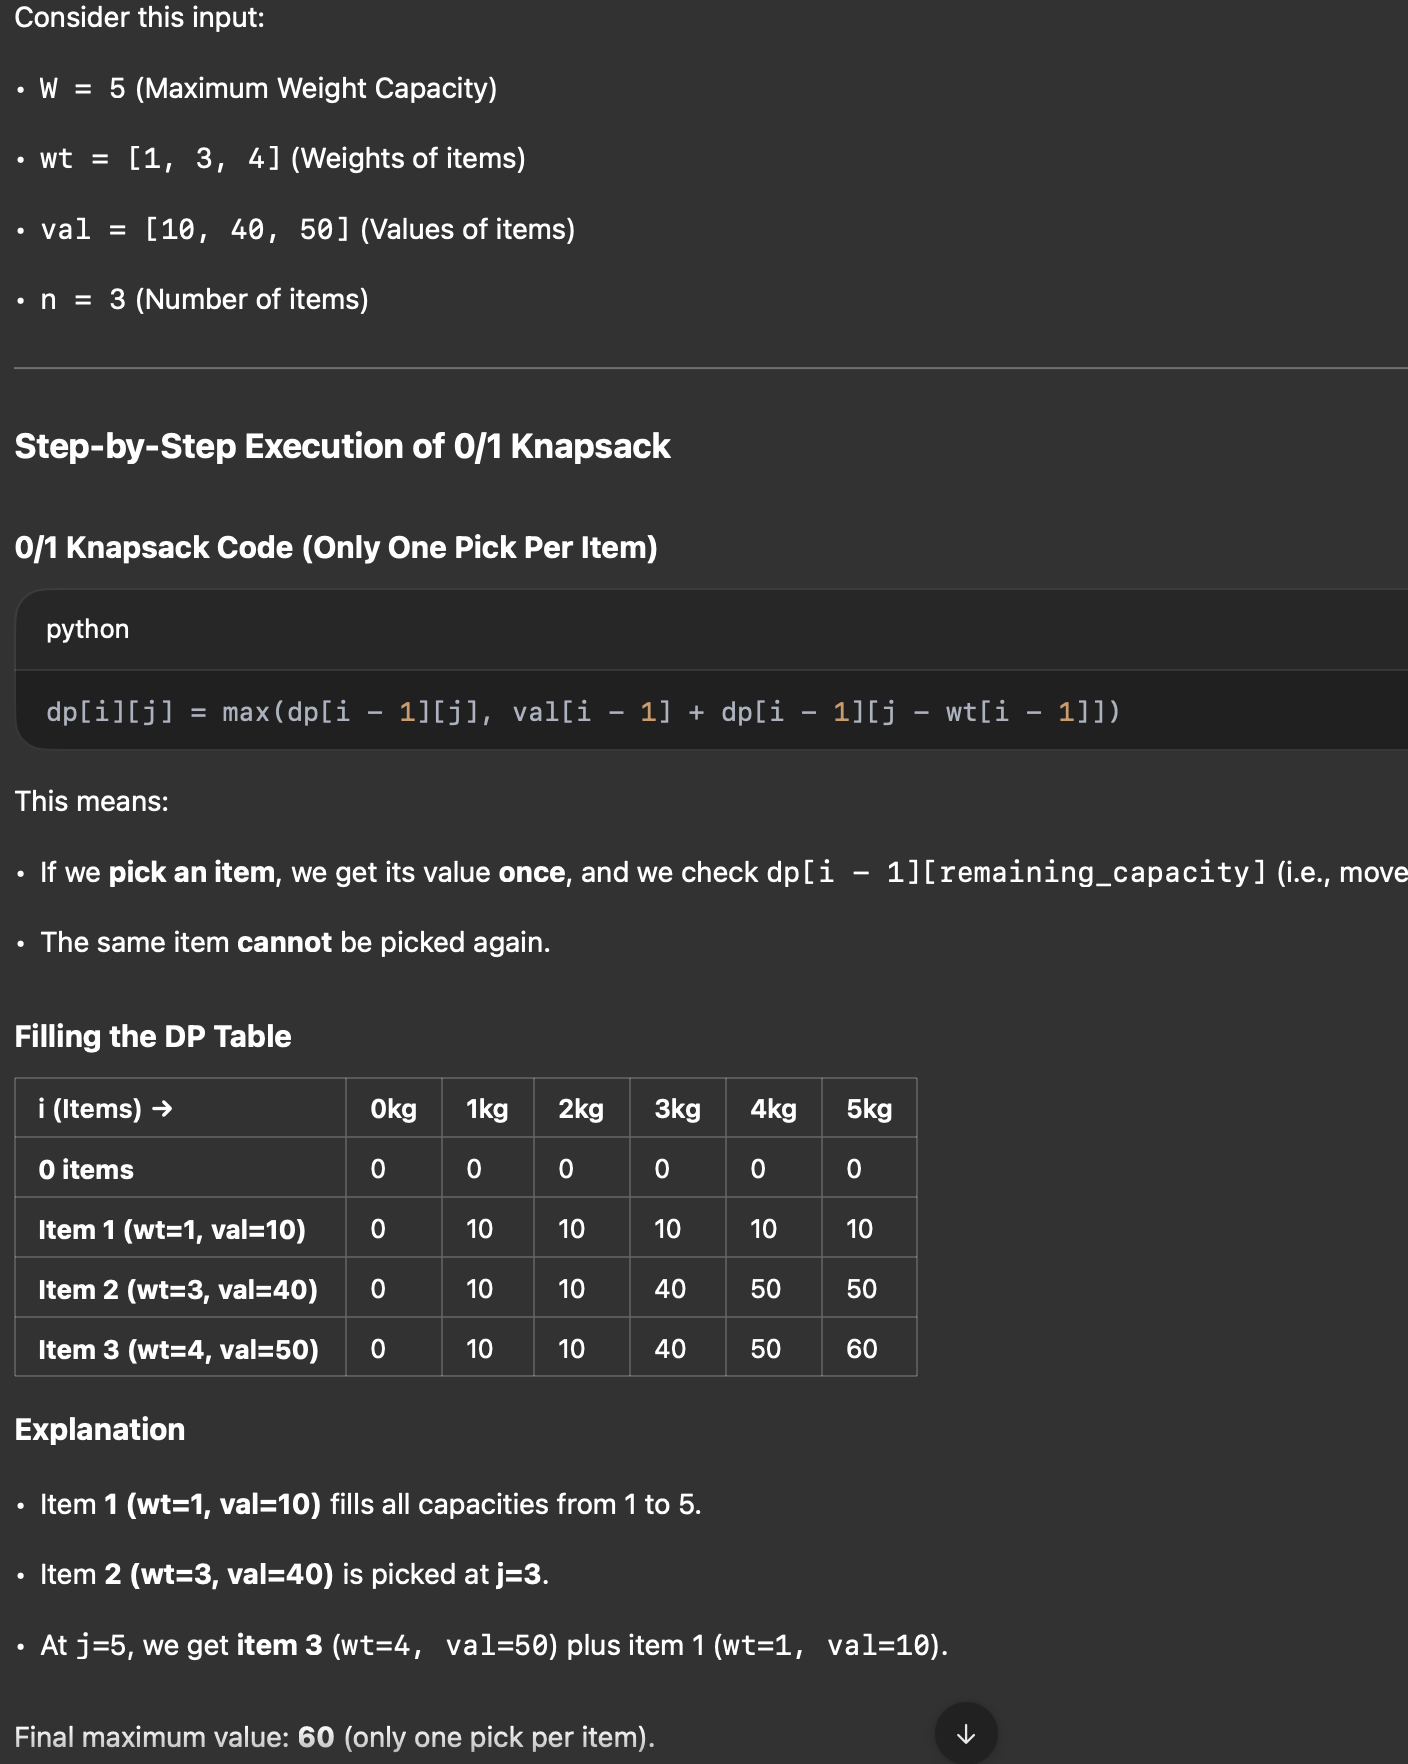
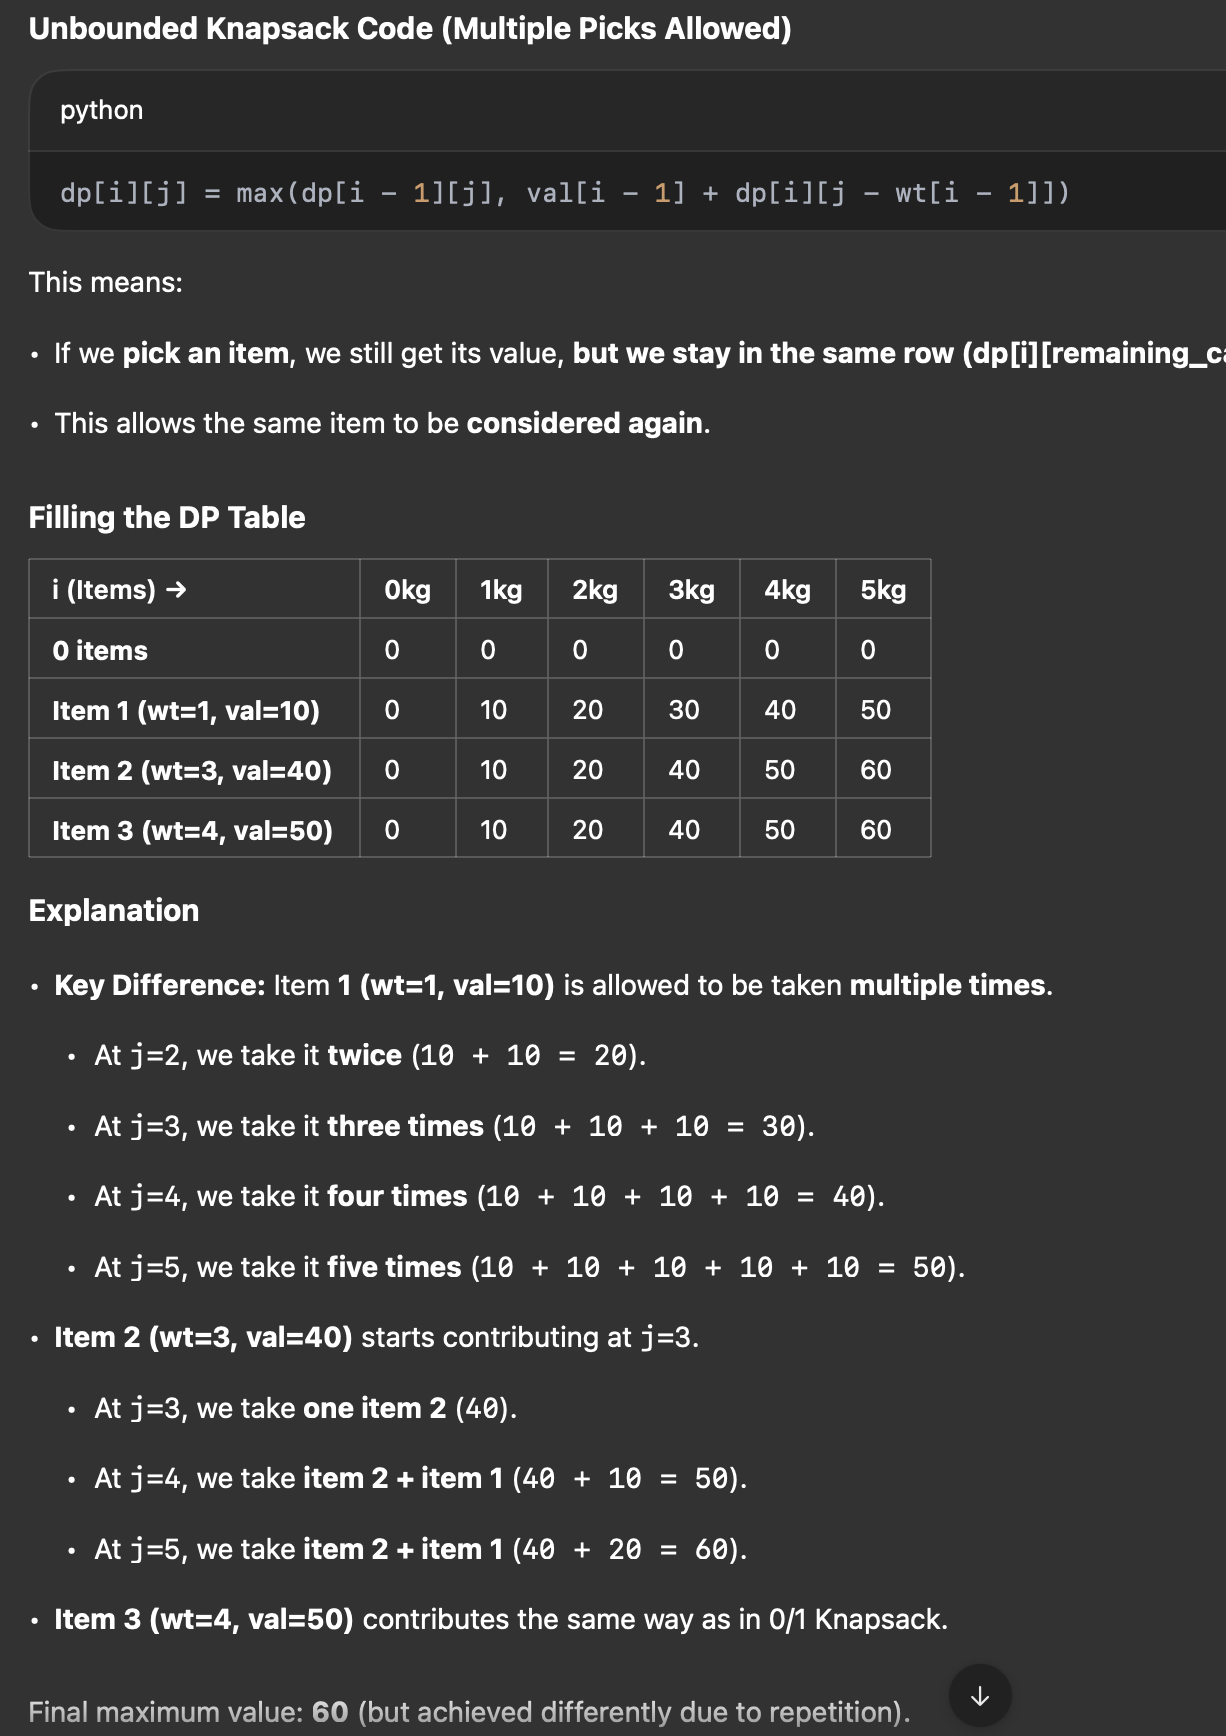

Why Does This Minor Code Change Allow Reuse of Items?

	1.	In 0/1 Knapsack, when we pick an item, we move to dp[i-1][j - wt[i-1]] (previous row).
	•	This ensures we don’t pick the same item again because i decreases.
	
    2.	In Unbounded Knapsack, when we pick an item, we stay at dp[i][j - wt[i-1]] (same row).
	•	This allows us to pick the same item again and again.

In [ ]:
Question 8: Rod cutting problem, Maximize the price 
Given: Length of rod and price array.
lenght[]: [1, 2, 3, 4, 5, 6, 7, 8]
price[]: [4, 6, 2, 7, 1, 3, 5, 7]
n = 5, total length of given rod

Y-axis: size of array, i=2 means consider first 2 elements.
X-axis: Lenght of rod, given total length of rod (ie. same as W)

def rod_cutting_2D_dp(lengths, price, n):
    num_lengths = len(lengths)
    dp = [[0] * (n + 1) for _ in range(num_lengths + 1)]  # DP table

    # Build the table in bottom-up manner
    for i in range(1, num_lengths + 1):  # Consider first 'i' rod pieces
        for j in range(1, n + 1):  # Rod length from 1 to n
            if lengths[i - 1] > j: 
                dp[i][j] = dp[i - 1][j]  # Exclude the piece if it's too large
            else:
                dp[i][j] = max(dp[i - 1][j], price[i - 1] + dp[i][j - lengths[i - 1]])

    return dp[num_lengths][n]  # Maximum price for full rod

# Example Usage
lengths = [1, 2, 3, 4, 5, 6, 7, 8]
price = [1, 5, 8, 9, 10, 17, 17, 20]
n = 8  # Total rod length

print("Maximum Obtainable Value:", rod_cutting_2D_dp(lengths, price, n))

In [ ]:
Question 9: Coin change problem, With the given denominations of coins, return the ways to get sum of total K.
- Coins are unlimited, can be used multiple times.

Sol: Whenever number of ways or counts are asked, just add + in above else condition.
- If value array is not given in question, then just ignore it and rest remain as it is.

def coinChangeWays(coins, n, K):
    dp = [[0] * (K + 1) for _ in range(n + 1)]

    # If sum is 0, there is 1 way to achieve it (by taking no coins)
    for i in range(n + 1):
        dp[i][0] = 1

    # Filling the DP table
    for i in range(1, n + 1):  # Iterate over coin denominations
        for j in range(1, K + 1):  # Iterate over sum from 1 to K
            if coins[i - 1] <= j:
                dp[i][j] = dp[i - 1][j] + dp[i][j - coins[i - 1]]
            else:
                dp[i][j] = dp[i - 1][j]

    return dp[n][K]

# Example Usage
coins = [1, 2, 3]  # Denominations
K = 5  # Target sum
n = len(coins)
print(coinChangeWays(coins, n, K))  # Output: 5




In [13]:
from typing import List

In [ ]:
Question 9: Coin change problem, With the given denominations of coins, return the ways to get sum of total K with minimum number of coins.
- Coins are unlimited, can be used multiple times.

Key Points:
1. When minimum is asked, we can not initialize our 0th row or column with 0, instead use infinity.
2. When min/max is asked, always add a value array, in condition when element is considered. If value array is not given, check if we can use "1 +", instead of adding value array elements. 
3. If number of ways is asked, always use "+", in condition when element is considered.

    
Solution: 

def coinChange(coins: List[int], amount: int) -> int:
    
    def coinChange(self, coins: List[int], amount: int) -> int:
        dp = [ [float('inf')] * (amount + 1) for _ in range(len(coins) + 1)]

        for i in range(1, len(coins) + 1):
            dp[i][0] = 0

        for i in range(1, len(coins) + 1):
            for j in range(1, amount + 1):
                if (coins[i-1] <= j):
                    dp[i][j] = min(dp[i-1][j], 1 + dp[i][j-coins[i-1]])
                else:
                    dp[i][j] = dp[i-1][j]

        return dp[len(coins)][amount] if dp[len(coins)][amount] != float('inf') else -1 


    def coinChange(self, coins: List[int], amount: int) -> int:
        """
            •	We iterate through each coin in coins.
            •	For each j (from coin to amount), we check:
            •	Without taking coin: dp[j] (previous value)
            •	Taking coin: 1 + dp[j - coin]
            •	Take the minimum of both.
        """
        dp = [float('inf')] * (amount + 1)
        dp[0] = 0  # Base case: 0 coins needed for sum 0

        for coin in coins:  # Process each coin
            for j in range(coin, amount + 1):  # Iterate through sum from `coin` to `amount`
                dp[j] = min(dp[j], 1 + dp[j - coin])

        return dp[amount] if dp[amount] != float('inf') else -1     
                
coins = [1, 2, 5]
K = 11
coinChange(coins, K)


# Longest Common Subsequence

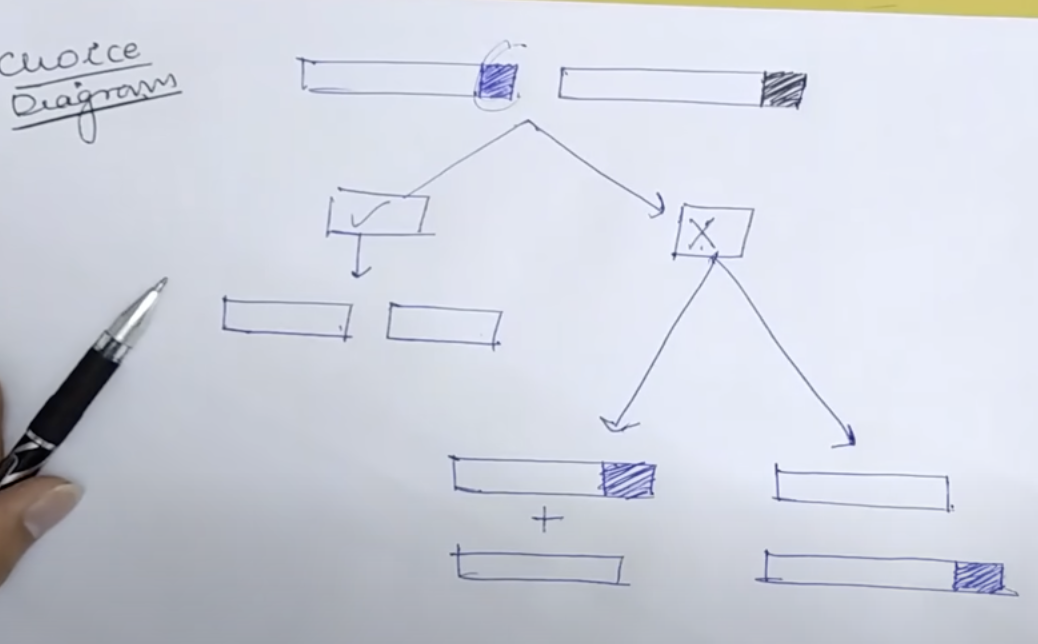
Choice Diagram:
1. if ith and jth character matches, then decrease both i-- and j-- and +1 in answer as it matches
2. Else, 
   - take max(i--, j and i, j--)

In [ ]:
Question 10: Longest Common subsequence
Return length of longest common sub-sequence. (non-continous)

A= "abcdgf"
B= "abedfhl"

Approach:
1. Base condition, that is smallest valid input
2. Choice Diagram
3. Input small in every Iteration. Move N to 0, in each iteration.



def longest_common_subsequence_recursive(x, y, n, m):
    """TC:  O(2^{\max(m, n)}) (Exponential)
       SC: O(max(n,m)), recursion stack
       In recursion, it is calculating same sub-problems everytime.
    """
    if (n == 0 || m == 0):
        return 0
    
    if x[n-1] == y[m-1]:
        return 1 + longest_common_subsequence(x, y, n-1, m-1)
    else:
        return max(longest_common_subsequence_recursive(x,y,n-1,m), longest_common_subsequence_recursive(x,y,n,m-1)
            
memo = [[-1] * (n + 1) for _ in range(m + 1)]  # Initialize memoization table
def lcs_memo(X, Y, m, n, memo):
    """TC: O(M*N), 
       SC: O(M*N) for the table
    """
    if m == 0 or n == 0:
        return 0

    if memo[m][n] != -1:  # Check if already computed
        return memo[m][n]

    if X[m-1] == Y[n-1]:  # If characters match
        memo[m][n] = 1 + lcs_memo(X, Y, m-1, n-1, memo)
    else:  # If characters do not match
        memo[m][n] = max(lcs_memo(X, Y, m-1, n, memo), lcs_memo(X, Y, m, n-1, memo))

    return memo[m][n]

def lcs_tabulation(X, Y):
    """ LCS top down approach
       TC: O(M*N), 
       SC: O(M*N) for the table
    """ 
    m, n = len(X), len(Y)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if X[i-1] == Y[j-1]:
                dp[i][j] = 1 + dp[i-1][j-1]
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])

    return dp[m][n]

# Example Usage
X = "abcde"
Y = "ace"
print(lcs_tabulation(X, Y))  # Output: 3


In [ ]:
Question 10: Longest Common sub-string

Idea:
- If string does not match, reset the lenght to zero.


def longest_common_substring(X, Y):
    """ Reset the lenght/count, if string does not matches, so we keep a max_length variable to keep track of max substring found.
    
    """
    m, n = len(X), len(Y)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    max_length = 0  # Stores the length of the longest common substring

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if X[i - 1] == Y[j - 1]:  # Characters match
                dp[i][j] = dp[i - 1][j - 1] + 1
                max_length = max(max_length, dp[i][j])  # Update max length
            else:
                dp[i][j] = 0  # Reset if characters don't match

    return max_length

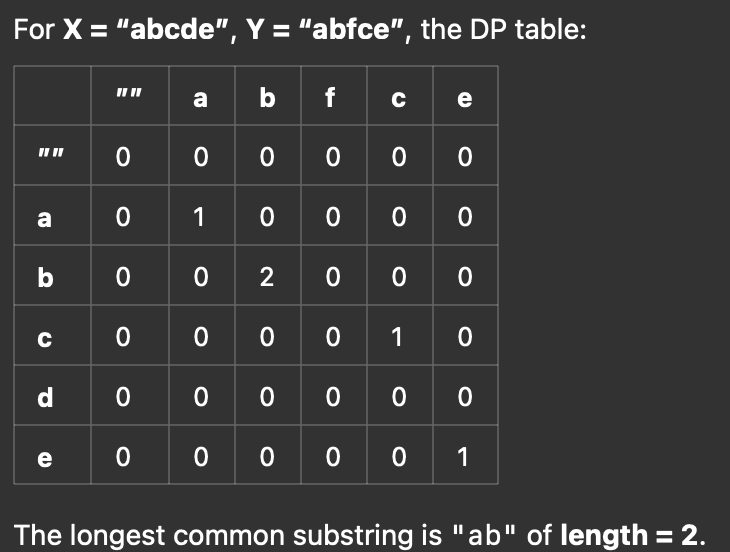

In [ ]:
Question 11: Print Longest Common sub-sequence

A = "acbcf"
B = "abcdaf"

       "" A[0] B[1] B[2]
        0  1    2    3   4 5 6 
""    0
B[0]  1
B[1]  2
B[2]  3
B[3]  4
B[4]  5

dp matrix 0th row and 0th column represents empty sting, ie. 0 means consider 0 elements of string.
    1 row/column in dp matrix  means, considering only first element.
    2 row/column in dp matrix  means, considering first 2 elements.


Logic:
  --------
  |A |C  |
  |B |D  |
  --------
To fill box D, 
  - if index i and j matches, we will put value of A + 1
  - else, max(B, C)

To get the values of sub-sequence, we can move in reverse direction from dp[N][M] to dp[0][0]
    
# Step 2: Trace Back to Find LCS String
here, dp[5][3] represents X[4] and Y[2]

    i, j = m, n
    lcs = []
    
    while i > 0 and j > 0:
        if X[i - 1] == Y[j - 1]:  # If characters match, add to result
            lcs.append(X[i - 1])
            i -= 1
            j -= 1
        elif dp[i - 1][j] > dp[i][j - 1]:  # Move in the direction of the larger value
            i -= 1
        else:
            j -= 1

    return "".join(reversed(lcs))


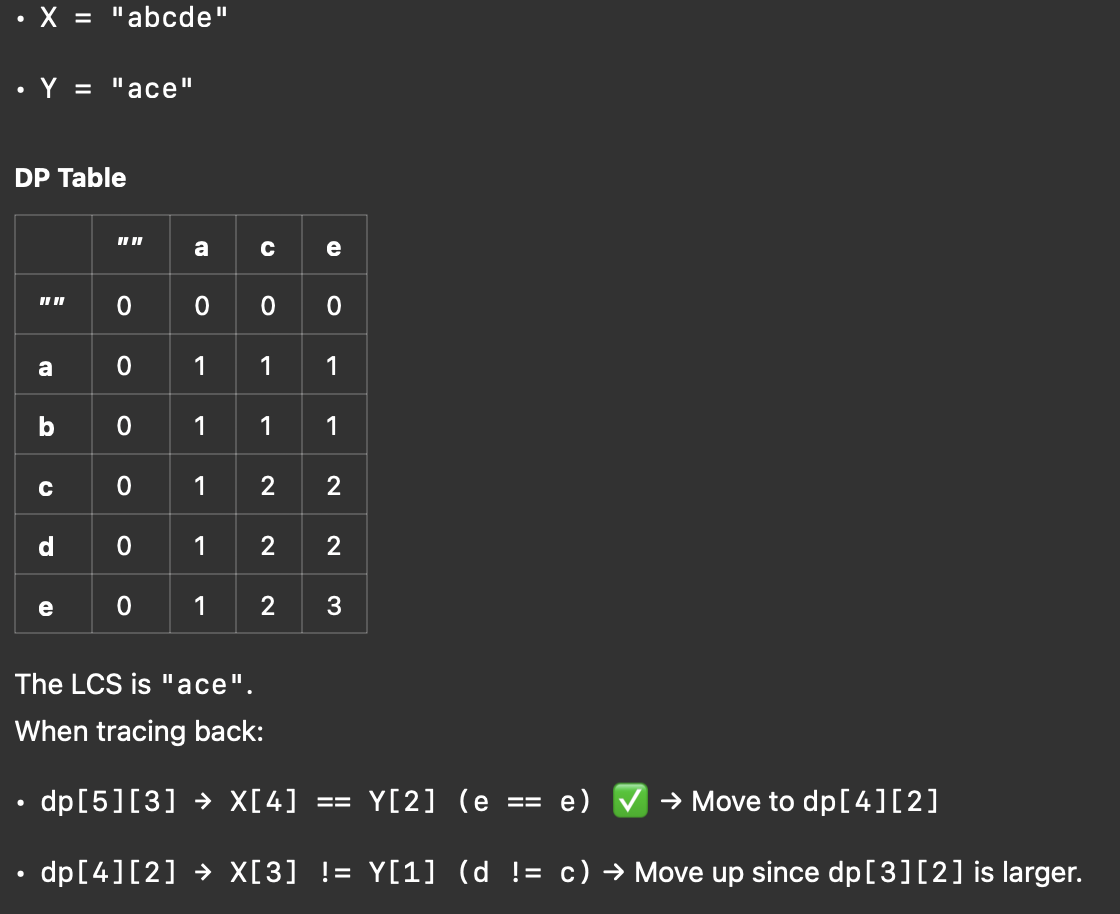

In [ ]:
Question 12: Shortest common super-sequence
Merge the given 2 string, such that it can produce both the words.
It is a sub-sequence, sequence should be same not necessary to be continous.
     
A = geek
B = eke
Output: geeke

Answer: len(A) + len(B) - len(LCS)


Question 16: Print the super-sequence


In [ ]:
Question 13: Minimum no. of insertion and deletion to convert string A to B.
string1 => convert to LCS => string2
No. of deletions = lenght(A) - LCS
No. of Insertion = length(B) - LCS

In [ ]:
Palindromic:
 - bcb, b, abcba

Question 14: Longest Palindromic sub-sequence
Solution: LCS(string1, reverse(string1))

Question 15: Minimum no. of deletion in a string to make it palindrome
Solution: len(string1) - LCS(string1, reverse(string1))

In [ ]:
Question 16: Longest repeating sub-sequence
Ex: AABEBCDD 
Output: ABD, as it appears two times in the given query.

Idea: LCS(string1, string1) and add a condition that i != j, as we don't same index to be repeated.

def longestRepeatingSubsequence(X: str) -> int:
    n = len(X)
    dp = [[0] * (n + 1) for _ in range(n + 1)]

    for i in range(1, n + 1):
        for j in range(1, n + 1):
            if X[i - 1] == X[j - 1] and i != j:  // addtional condition in LCS code.
                dp[i][j] = 1 + dp[i - 1][j - 1]
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])

    return dp[n][n]


In [ ]:
Question 17: sub-sequence pattern matching, If string A is a sub-sequence of string B.
Sol: If length of LCS(string1, string2) == min(len(string1), len(string2)) 
   then answer is true as the smaller input string is same as LCS.

Question 18: Minimum no. of Insertion to make string palindrome
Solution: No. of Insertion = len(string1) - LCS(string1, reverse(string1)


# Matrix Chain Multiplication

In [ ]:
Problem Identification: We try to find multiple answer as temp answers and take min/max of all temp answers.
- We move k continously in array to find all possible multiple answers and take min/max of all.
- Recognizing MCM Problems: Look for partitioning problems where multiple splits are possible.



Approach:
- In the given array, for nearly start and end elements are ark pointers as i and j.
- Break intermidiate elements at k in b/w, then solve
  i to k and k+1 to j recursively.

Recursive Template Code:
def solve(i, j):
    if (i>j):
        return 0

    for k in range(i, j):
        temp_answer = solve(arr, i, k) [Operator] solve(arr, k+1, j)
        final_answer = temp_answer + [opeation function]



In [ ]:
Question 18: minimum cost to multiple matrix
Idea:
A = 2*3 and B = 3*6
Cost to multiply matrix A and B = 2*3*6

Inputs:
A = 10 * 30
B = 30 * 5
C = 5 * 60

Approach 1: (AB)C
       => (10 * 30 * 5) + C => 1500 + C  => 1500  + (10 * 5 *  60) => 4500
Approach 2: A(BC)
       => 2700

Approach 1 is first temp answer and Approach 2 is second temp answer, the final answer is 2700 which is minimum.

Solution Steps:
1.  Find i and j
2. Base condition
3. k loop start and end.
4. function of temp_answer.



0 1 2 3 4 5 6 7 8 9 
  i               j

[40, 20, 30, 10, 30]
Case 1: k from i to j
  i to k           k+1 to j
   40*20           10*30 (when k+1 == j), so move k from i to j-1
   20*30
   30*10
   10*30

Scheme 1 to write for loop:
Move k: from i to j-1
   solve(i, k)
   solve(k+1, j)

Scheme 2 to write for loop:
Move k: from i+1 to j
   solve(i, k-1)
   solve(k, j)

Use Either Case 1 or Case 2.

In [ ]:
import sys

def matrix_chain_recursive(arr, i, j):
    """ TC: 2 ^n (Exponential) 
        k will move from i=1 (ie. value 20 second value) to j-1 (ie. 10) second last index value
        The first recursive call when i == j, will return 0
        The last recursive call when k+1 == j, will return 0
    """
    if i >= j:
        return 0  # No multiplication needed for a single matrix

    min_cost = sys.maxsize

    for k in range(i, j):
        cost = (matrix_chain_recursive(arr, i, k) +
                matrix_chain_recursive(arr, k + 1, j) +
                arr[i-1] * arr[k] * arr[j])

        min_cost = min(min_cost, cost)

    return min_cost


def matrix_chain_memoized(arr, i, j, dp):
    """ TC: O(N ^2 * N for for loop) => N ^3
    """
    if i >= j:
        return 0

    if dp[i][j] != -1:
        return dp[i][j]

    min_cost = sys.maxsize

    for k in range(i, j):
        cost = (matrix_chain_memoized(arr, i, k, dp) +
                matrix_chain_memoized(arr, k + 1, j, dp) +
                arr[i-1] * arr[k] * arr[j])

        min_cost = min(min_cost, cost)

    dp[i][j] = min_cost
    return dp[i][j]

    
# Example Usage
           i,k  k  k   j
arr = [40, 20, 30, 10, 30]
n = len(arr)
dp = [[-1] * n for _ in range(n)]
print(matrix_chain_recursive(arr, 1, n-1))  # Output: 26000

In [ ]:
# Visualization when k is at index 2 (ie. value 30)
# i and J will remain at the same postion, only k will move as in each case we want to compute answer for full array, 
   # with each incremenet in k, we are just trying to calcuate different PnC to calculate total answer, and will take min of all.

           i.  k.      j
arr = [40, 20, 30, 10, 30]
       --------- --------
       Cost1.      Cost2

Cost 1 = 40 * 20 * 30 (solve(i, k)
Cost 2 = 30 * 10 * 30 (solve(k+1, j)
Total cost = Cost 1 + Cost 2 + Cost to multiply matrix after cost1 and cost2 operation.
Total cost  = Cost 1 + Cost 2 + Cost 3 (40*30*30)



In [ ]:
Question 19: Split the string, such that each chuck is a palindrom.
Worst case: split each letter, as one character is a palindrome in itself.
Ex: if complete string is palindrome then, return zero.

Ex: nitin

Case 1:
 n | iti
solve(i, k) + solve(k+1, j) + cost of merge these two solutions.
n           +  iti        +  1 (as we have added a partition b/w n and itin)



def is_palindrome(s, i, j):
    return s[i:j+1] == s[i:j+1][::-1]

def min_cuts(s, i, j):
    """ TC: 2^N
    """
    # if i>=j means string is empty or single character. (liek "", "a")
    # "abcba" then also return zero, as there is no need to make any additional partitions.
    
    if i >= j or is_palindrome(s, i, j):  
        return 0  

    min_partitions = float('inf')

    for k in range(i, j):  
        temp = 1 + min_cuts(s, i, k) + min_cuts(s, k+1, j)  
        min_partitions = min(min_partitions, temp)

    return min_partitions


dp = [[-1] * n for _ in range(n)]
def min_cuts_memo(s, i, j, dp):
    """
    """
    if i >= j or is_palindrome(s, i, j):
        return 0

    if dp[i][j] != -1:
        return dp[i][j]

    min_partitions = float('inf')

    for k in range(i, j):
        temp = 1 + min_cuts_memo(s, i, k, dp) + min_cuts_memo(s, k+1, j, dp)
        min_partitions = min(min_partitions, temp)

    dp[i][j] = min_partitions
    return dp[i][j]


def min_cuts_memo(s, i, j, dp):
    """
    """
    if i >= j or is_palindrome(s, i, j):
        return 0

    if dp[i][j] != -1:
        return dp[i][j]

    min_partitions = float('inf')

    for k in range(i, j):
        if dp[i][k] == -1:
            dp[i][k] = min_cuts_memo(s, i, k, dp)

        if dp[k+1][j] == -1:
            dp[k+1][j] = min_cuts_memo(s, k+1, j, dp)

        temp = 1 + dp[i][k] + dp[k+1][j]
        min_partitions = min(min_partitions, temp)

    dp[i][j] = min_partitions
    return dp[i][j]

In [ ]:
Question 20: Evaluate Expression to True boolean paraenthesis
Input: T|F&T^F
Output 1: (T)|(F&T^F) when k at k= index 1 (ie at |)

Solution steps: 
1. Find i and j
2. Base Consdition
3. Find k loop
4. final_ans = fun(temp_answer)

T |F&T^F
i k k k j
i and j are on boolean T/F
k will only move on characters.

def countWaysMemo(expr, i, j, isTrue, dp):
    """ It returns the number of ways the array i to j can be converted to given boolean.
        [i  k   j]
         --- ----
        To combine answer:  left solution    + (k as given operator)  + right solution
    """

    if i > j:
        return 0
    if i == j:
        return 1 if (isTrue and expr[i] == 'T') or (not isTrue and expr[i] == 'F') else 0

    if dp[i][j][isTrue] != -1:
        return dp[i][j][isTrue]

    ways = 0
    for k in range(i + 1, j, 2):
        leftTrue = countWaysMemo(expr, i, k - 1, True, dp)
        leftFalse = countWaysMemo(expr, i, k - 1, False, dp)
        rightTrue = countWaysMemo(expr, k + 1, j, True, dp)
        rightFalse = countWaysMemo(expr, k + 1, j, False, dp)

        if expr[k] == '|':
            if isTrue:
                ways += leftTrue * rightTrue + leftTrue * rightFalse + leftFalse * rightTrue
            else:
                ways += leftFalse * rightFalse

        elif expr[k] == '&':
            if isTrue:
                ways += leftTrue * rightTrue
            else:
                ways += leftTrue * rightFalse + leftFalse * rightTrue + leftFalse * rightFalse

        elif expr[k] == '^':
            if isTrue:
                ways += leftTrue * rightFalse + leftFalse * rightTrue
            else:
                ways += leftTrue * rightTrue + leftFalse * rightFalse

    dp[i][j][isTrue] = ways
    return ways

expr = "T|F&T"
n = len(expr)
dp = [[[-1] * 2 for _ in range(n)] for _ in range(n)]
print(countWaysMemo(expr, 0, n - 1, True, dp))



In [ ]:
Question 21: Scrambled String: Create a binary tree of given string, such that leaf nodes has a single character only.
    any two child of one parent node and that must be non-leaf nodes can be swaped.
    
Return True, if stirng1 and string2 are scrambled strings.


from functools import lru_cache

def isScramble(s1: str, s2: str) -> bool:
    """ For memoization: the chaning inputs are two string, so 2D matrix won't work here, instead use a dictionary.
     { (s1, s2): boolean }
    """
    dp = {}

    def helper(s1, s2):
        if (s1, s2) in dp:
            return dp[(s1, s2)]
        if len(s1) != len(s2):
            return False
            
        if s1 == s2:
            return True

        # Optimization (not necessary):	Two strings can only be scrambled versions of each other if they have the same characters in the same frequency.
        if sorted(s1) != sorted(s2):  # Pruning
            return False

        n = len(s1)
        for k in range(1, n):
            # Case 1: Without swapping
            if helper(s1[:k], s2[:k]) and helper(s1[k:], s2[k:]):
                dp[(s1, s2)] = True
                return True
            # Case 2: With swapping
            if helper(s1[:k], s2[n-k:]) and helper(s1[k:], s2[:n-k]):
                dp[(s1, s2)] = True
                return True

        dp[(s1, s2)] = False
        return False

    return helper(s1, s2)


In [ ]:
Question 22: Egg Dropping Problem
Input: No. of eggs: 3
       No. of floors: 5
Threshold floor, return Kth floor if we drop the egg it won't break the egg and at K+1 th floor it will break the egg.
Return: minimum no. of attempts


Total floors: f
Total Eggs: e

1. Iteration of k
  - Check k from 1 (ie. first floor) to last floor (k)

          solve(e, f)
            /    \
           /      \
solve(e-1, k-1)   solve(e, f-k)
 Case 1               Case 2

Case 1: Egg Break
- Reduce one egg (e-1)
- For next we just need to check all below floors than k

Case 2: Egg not break
- No need to reduce egg (e)
- Check all above floor than k (f-k)


def eggDropRecursive(e, f, dp):
    """TC: O(E × F²)
    """
    # Base Cases
    if f == 0:  # No floors, no trials needed
        return 0
    if f == 1:  # One floor, one trial needed
        return 1
    if e == 1:  # One egg, must check each floor
        return f

    # If already computed, return stored result
    if (e, f) in dp:
        return dp[(e, f)]

    # Initialize minimum attempts to a large value
    min_attempts = float('inf')

    # Try dropping from each floor (1 to f)
    for x in range(1, f + 1):
        # Compute worst-case scenario
        break_case = eggDropRecursive(e - 1, x - 1, dp)  # Egg breaks
        no_break_case = eggDropRecursive(e, f - x, dp)  # Egg does not break

        # max: To find the worst case
        # No. of floors remaining to check, after droping the current egg.
        worst_case_attempts = 1 + max(break_case, no_break_case) 

        # min: Store the minimum attempts required
        min_attempts = min(min_attempts, worst_case_attempts)

    # Store result in memoization table
    dp[(e, f)] = min_attempts
    return min_attempts

# Wrapper function
def eggDrop(eggs, floors):
    dp = {}  # Dictionary for memoization
    return eggDropRecursive(eggs, floors, dp)

    
    
    

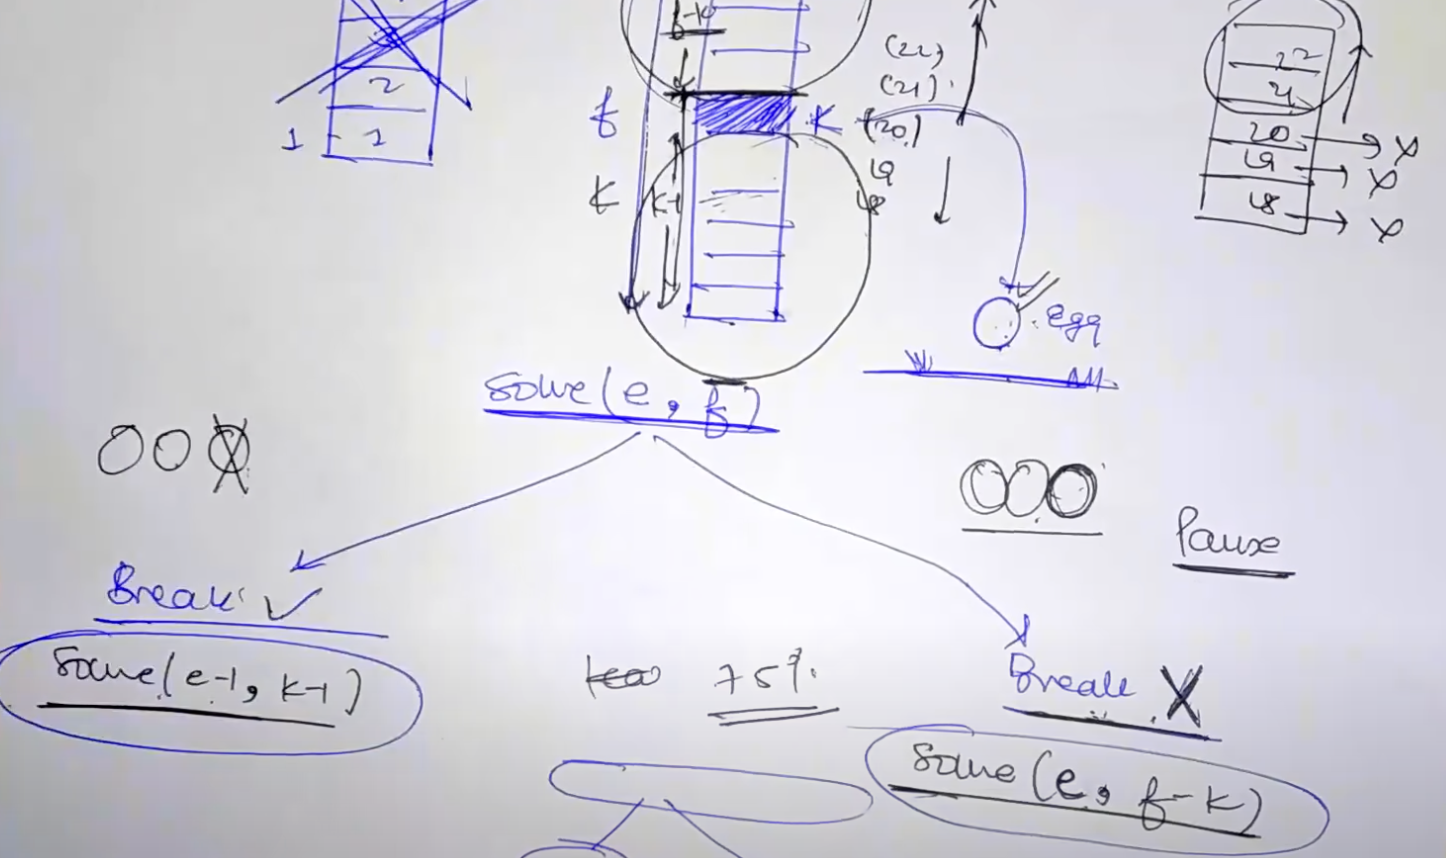